# TT-21 — KNN Regressor · Định giá nhà theo "các căn tương tự"

**Bộ dữ liệu:** California Housing (20.640 dòng × 8 đặc trưng, nhãn `MedHouseVal` đơn vị 100.000 USD).

**Ý tưởng:** KNN Regressor chính là phương pháp **so sánh (comparable sales)** mà thẩm định viên
bất động sản vẫn dùng — tìm vài căn tương tự vừa bán trong khu rồi lấy giá trung bình:

$$\hat{y} = \frac{1}{K}\sum_{i \in N_K(x)} y_i
\quad\text{hoặc, với } \texttt{weights='distance'}:\quad
\hat{y} = \frac{\sum_i y_i/d_i}{\sum_i 1/d_i}$$

**Mục tiêu:** chứng minh KNN **thắng** Linear Regression (TT-11) trên chính bộ dữ liệu này, và
khai thác ưu thế riêng của KNN: **chỉ ra được căn cứ** là những căn nhà cụ thể nào.

In [1]:
import sys, time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GOC = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(GOC))

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.data import DAC_TRUNG, RANDOM_STATE, cac_can_tuong_tu, chia_du_lieu, tai_du_lieu, tao_pipeline

pd.set_option("display.width", 120, "display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
BC = GOC / "reports"; BC.mkdir(exist_ok=True)

## 1. Nạp dữ liệu và xử lý outlier

`AveRooms`, `AveBedrms`, `AveOccup` là tỉ số *tổng / số hộ gia đình* nên có vài dòng giá trị vô lý
(khu nghỉ dưỡng, doanh trại...). Với KNN — một mô hình **dựa hoàn toàn vào khoảng cách** — những
dòng này kéo lệch không gian đặc trưng, nên cần cắt trước.

In [2]:
tho = tai_du_lieu(loc_outlier=False)
df = tai_du_lieu(loc_outlier=True)

print(f"Gốc: {tho.shape[0]:,} dòng → sau lọc outlier: {df.shape[0]:,} dòng "
      f"(bỏ {tho.shape[0]-df.shape[0]:,} dòng, {(1-len(df)/len(tho)):.2%})")
print(f"Nhãn bị chặn trần tại 5.0 (500k USD): {(df.MedHouseVal >= 5.0).mean():.2%} — "
      "KNN sẽ không bao giờ dự đoán vượt mức này (không ngoại suy được).")
df.describe().T

Gốc: 20,640 dòng → sau lọc outlier: 20,495 dòng (bỏ 145 dòng, 0.70%)
Nhãn bị chặn trần tại 5.0 (500k USD): 4.81% — KNN sẽ không bao giờ dự đoán vượt mức này (không ngoại suy được).


,count,mean,std,min,25%,50%,75%,max
MedInc,"20,495.0000",3.8714,1.8972,0.4999,2.5643,3.5353,4.7465,15.0001
HouseAge,"20,495.0000",28.6970,12.5732,1.0000,18.0000,29.0000,37.0000,52.0000
AveRooms,"20,495.0000",5.3116,1.3169,0.8462,4.4367,5.2226,6.0336,14.8519
AveBedrms,"20,495.0000",1.0726,0.1596,0.3333,1.0059,1.0482,1.0982,3.7164
Population,"20,495.0000","1,428.8997","1,128.3797",3.0000,792.0000,"1,170.0000","1,727.0000","35,682.0000"
AveOccup,"20,495.0000",2.9211,0.7657,0.7500,2.4316,2.8204,3.2817,9.9545
Latitude,"20,495.0000",35.6212,2.1313,32.5400,33.9300,34.2500,37.7100,41.9500
Longitude,"20,495.0000",-119.5705,2.0047,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
MedHouseVal,"20,495.0000",2.0710,1.1547,0.1500,1.1975,1.8010,2.6520,5.0000


### Vì sao KNN hợp với bộ này?

Nhìn bản đồ giá theo `Latitude`/`Longitude`: giá **không** thay đổi tuyến tính theo toạ độ mà tạo
thành các **cụm cục bộ** (vùng vịnh San Francisco, Los Angeles, ven biển...). Linear Regression
bắt rất kém dạng quan hệ này, còn giả định của KNN — *hàng xóm gần nhau thì giá giống nhau* —
lại **đúng gần như tuyệt đối** với bất động sản.

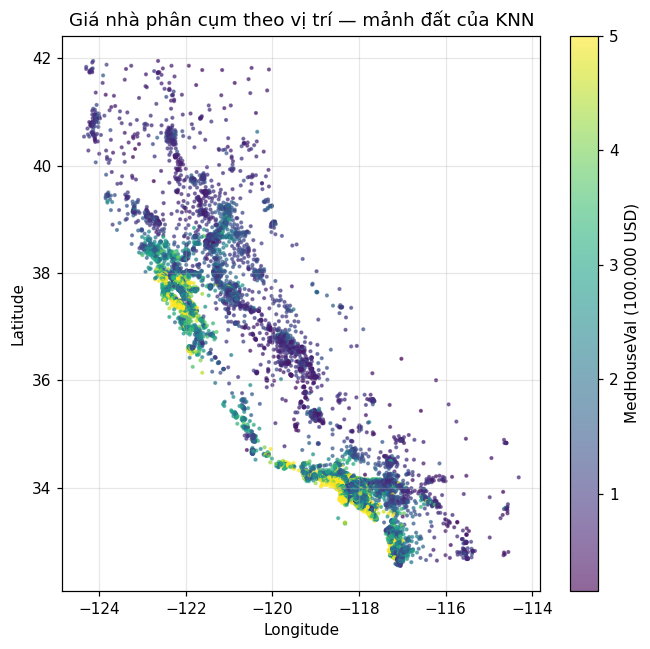

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 6))
sc = ax.scatter(df.Longitude, df.Latitude, c=df.MedHouseVal, s=3, cmap="viridis", alpha=.6)
plt.colorbar(sc, ax=ax, label="MedHouseVal (100.000 USD)")
ax.set(xlabel="Longitude", ylabel="Latitude", title="Giá nhà phân cụm theo vị trí — mảnh đất của KNN")
plt.tight_layout(); plt.show()

In [4]:
X_train, X_test, y_train, y_test = chia_du_lieu(df)
print(f"Train {len(X_train):,} · Test {len(X_test):,}")

Train 16,396 · Test 4,099


## 2–4. Baseline · và vì sao **bắt buộc** phải chuẩn hoá

`Population` có đơn vị hàng nghìn, `AveBedrms` quanh 1. Khoảng cách Euclid khi chưa chuẩn hoá gần
như **chỉ còn là chênh lệch Population** — mọi đặc trưng khác bị vô hiệu hoá.

In [5]:
def danh_gia(model, ten):
    t0 = time.perf_counter(); model.fit(X_train, y_train); t_train = time.perf_counter() - t0
    du_doan = model.predict(X_test)
    mot_can = X_test.iloc[[0]]; model.predict(mot_can)
    t0 = time.perf_counter()
    for _ in range(20): model.predict(mot_can)
    return {"Mô hình": ten,
            "RMSE_train": root_mean_squared_error(y_train, model.predict(X_train)),
            "RMSE_test": root_mean_squared_error(y_test, du_doan),
            "R2_test": r2_score(y_test, du_doan),
            "Train (s)": t_train,
            "Dự đoán 1 căn (ms)": (time.perf_counter() - t0) / 20 * 1000}

bang_baseline = pd.DataFrame([
    danh_gia(DummyRegressor(strategy="mean"), "Dummy (giá trung bình)"),
    danh_gia(Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())]), "Linear Regression (TT-11)"),
    danh_gia(tao_pipeline(k=5, weights="uniform", chuan_hoa=False), "KNN K=5 — KHÔNG chuẩn hoá"),
    danh_gia(tao_pipeline(k=5, weights="uniform", chuan_hoa=True), "KNN K=5 — CÓ chuẩn hoá"),
])
bang_baseline

,Mô hình,RMSE_train,RMSE_test,R2_test,Train (s),Dự đoán 1 căn (ms)
0,Dummy (giá trung bình),1.1558,1.1500,-0.0001,0.0011,0.3569
1,Linear Regression (TT-11),0.6712,0.6789,0.6515,0.0187,0.9531
2,KNN K=5 — KHÔNG chuẩn hoá,0.8536,1.0658,0.1410,0.0195,33.5937
3,KNN K=5 — CÓ chuẩn hoá,0.4902,0.5909,0.7360,0.0330,48.4678


> **Nhận xét:** KNN không chuẩn hoá tệ hơn cả Linear Regression. Chỉ cần thêm `StandardScaler`,
> cùng một thuật toán, cùng một K, RMSE giảm mạnh. Đây là cạm bẫy số 1 của KNN.

## 5. Chọn K — và hiện tượng `K = 1`

Quy tắc: **chọn K bằng tập validation tách từ train**, tuyệt đối không nhìn vào test.
Với `K = 1` và `weights='uniform'`, RMSE train **bằng 0** vì hàng xóm gần nhất của một điểm train
chính là bản thân nó (khoảng cách 0) → mô hình *thuộc lòng* dữ liệu, không hề tổng quát hoá.
Với `weights='distance'` thì RMSE train = 0 với **mọi K** (khoảng cách 0 ⇒ trọng số vô hạn).
Nghĩa là: **RMSE train của KNN không dùng để chọn K được.**

K tốt nhất theo validation = 21 (weights='distance', RMSE_val = 0.5731)


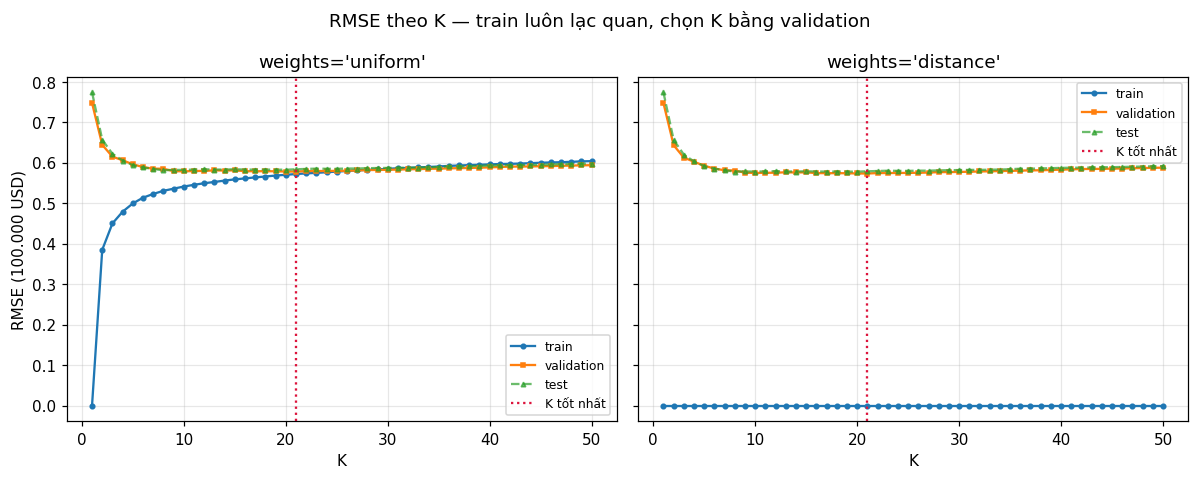

In [6]:
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=.2, random_state=RANDOM_STATE)
DS_K = range(1, 51)

dong = []
for weights in ("uniform", "distance"):
    for k in DS_K:
        pipe = tao_pipeline(k=k, weights=weights).fit(X_fit, y_fit)
        dong.append({"weights": weights, "K": k,
                     "RMSE_train": root_mean_squared_error(y_fit, pipe.predict(X_fit)),
                     "RMSE_val": root_mean_squared_error(y_val, pipe.predict(X_val)),
                     "RMSE_test": root_mean_squared_error(y_test, pipe.predict(X_test))})
bang_K = pd.DataFrame(dong)

tot = bang_K.loc[bang_K.RMSE_val.idxmin()]
K_TOT, WEIGHTS_TOT = int(tot.K), tot.weights
print(f"K tốt nhất theo validation = {K_TOT} (weights='{WEIGHTS_TOT}', RMSE_val = {tot.RMSE_val:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, w in zip(axes, ("uniform", "distance")):
    p = bang_K[bang_K.weights == w]
    ax.plot(p.K, p.RMSE_train, "o-", ms=3, label="train")
    ax.plot(p.K, p.RMSE_val, "s-", ms=3, label="validation")
    ax.plot(p.K, p.RMSE_test, "^--", ms=3, alpha=.7, label="test")
    ax.axvline(p.loc[p.RMSE_val.idxmin(), "K"], color="crimson", ls=":", label="K tốt nhất")
    ax.set(xlabel="K", title=f"weights='{w}'"); ax.legend(fontsize=8)
axes[0].set_ylabel("RMSE (100.000 USD)")
fig.suptitle("RMSE theo K — train luôn lạc quan, chọn K bằng validation")
plt.tight_layout(); plt.savefig(BC / "rmse_theo_K.png"); plt.show()

## 6–7. `uniform` vs `distance` · `euclidean` vs `manhattan`

- `distance`: căn càng gần càng nặng ký — hợp với thẩm định giá (căn cùng dãy phố nặng hơn căn cách 2 km).
- `manhattan` (p=1) thường ổn định hơn `euclidean` khi số chiều tăng vì ít bị một đặc trưng lệch chi phối.

In [7]:
dong = []
for weights in ("uniform", "distance"):
    for metric in ("euclidean", "manhattan"):
        dong.append(danh_gia(tao_pipeline(k=K_TOT, weights=weights, metric=metric),
                             f"{weights} · {metric}"))
bang_wm = pd.DataFrame(dong).sort_values("RMSE_test")
WEIGHTS_TOT, METRIC_TOT = bang_wm.iloc[0]["Mô hình"].split(" · ")
print(f"Cấu hình tốt nhất: weights='{WEIGHTS_TOT}', metric='{METRIC_TOT}'")
bang_wm

Cấu hình tốt nhất: weights='distance', metric='manhattan'


,Mô hình,RMSE_train,RMSE_test,R2_test,Train (s),Dự đoán 1 căn (ms)
3,distance · manhattan,0.0000,0.5488,0.7722,0.0510,89.7591
1,uniform · manhattan,0.5425,0.5532,0.7686,0.0193,89.9612
2,distance · euclidean,0.0000,0.5728,0.7518,0.0199,68.8545
0,uniform · euclidean,0.5632,0.5774,0.7478,0.0330,62.5777


## 8. ⭐ Thí nghiệm trọng số vị trí

Sau chuẩn hoá, mọi đặc trưng có "tiếng nói" ngang nhau. Nhưng trong bất động sản, **vị trí quan
trọng hơn số phòng**. Ta nhân `Latitude`/`Longitude` với hệ số 1 / 2 / 3 / 5 *sau khi scale*
→ ép KNN ưu tiên tìm hàng xóm **địa lý** trước, rồi mới xét các đặc trưng còn lại.

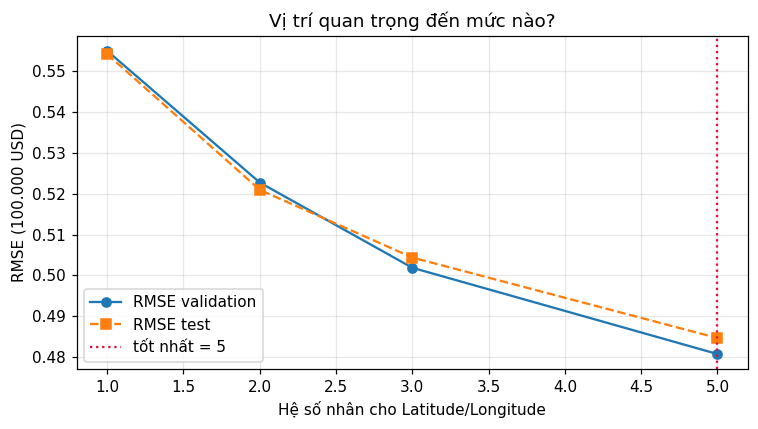

,Hệ số Lat/Lon,RMSE_val,RMSE_test,R2_test
0,1,0.5549,0.5541,0.7678
1,2,0.5227,0.5209,0.7948
2,3,0.5019,0.5044,0.8076
3,5,0.4808,0.4847,0.8223


In [8]:
dong = []
for w in (1, 2, 3, 5):
    pipe = tao_pipeline(k=K_TOT, weights=WEIGHTS_TOT, metric=METRIC_TOT, w_vi_tri=w).fit(X_fit, y_fit)
    dong.append({"Hệ số Lat/Lon": w,
                 "RMSE_val": root_mean_squared_error(y_val, pipe.predict(X_val)),
                 "RMSE_test": root_mean_squared_error(y_test, pipe.predict(X_test)),
                 "R2_test": r2_score(y_test, pipe.predict(X_test))})
bang_vitri = pd.DataFrame(dong)
W_TOT = float(bang_vitri.loc[bang_vitri.RMSE_val.idxmin(), "Hệ số Lat/Lon"])

plt.figure(figsize=(7, 4))
plt.plot(bang_vitri["Hệ số Lat/Lon"], bang_vitri.RMSE_val, "o-", label="RMSE validation")
plt.plot(bang_vitri["Hệ số Lat/Lon"], bang_vitri.RMSE_test, "s--", label="RMSE test")
plt.axvline(W_TOT, color="crimson", ls=":", label=f"tốt nhất = {W_TOT:g}")
plt.xlabel("Hệ số nhân cho Latitude/Longitude"); plt.ylabel("RMSE (100.000 USD)")
plt.title("Vị trí quan trọng đến mức nào?"); plt.legend()
plt.tight_layout(); plt.savefig(BC / "trong_so_vi_tri.png"); plt.show()
bang_vitri

> **Kết luận cần rút ra:** nếu RMSE giảm khi tăng hệ số, nghĩa là mô hình đang nói với ta rằng
> *vị trí mang nhiều thông tin về giá hơn các đặc trưng còn lại* — đúng câu cửa miệng của dân
> bất động sản: **location, location, location**. Nếu tăng quá mạnh RMSE lại tăng, đó là lúc
> KNN bỏ qua hoàn toàn thu nhập/diện tích và chỉ còn so sánh theo bản đồ.

In [9]:
# Chốt mô hình cuối + kiểm chứng bằng 5-fold CV trên train
knn = tao_pipeline(k=K_TOT, weights=WEIGHTS_TOT, metric=METRIC_TOT, w_vi_tri=W_TOT).fit(X_train, y_train)
cv = -cross_val_score(knn, X_train, y_train, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                      scoring="neg_root_mean_squared_error", n_jobs=-1)
print(f"Cấu hình chốt: K={K_TOT} · weights='{WEIGHTS_TOT}' · metric='{METRIC_TOT}' · hệ số vị trí={W_TOT:g}")
print(f"RMSE 5-fold CV (train): {cv.mean():.4f} ± {cv.std():.4f}")
print(f"RMSE test: {root_mean_squared_error(y_test, knn.predict(X_test)):.4f} · "
      f"R² test: {r2_score(y_test, knn.predict(X_test)):.4f}")

Cấu hình chốt: K=21 · weights='distance' · metric='manhattan' · hệ số vị trí=5
RMSE 5-fold CV (train): 0.4938 ± 0.0113
RMSE test: 0.4785 · R² test: 0.8269


## 9. ⭐ Ưu thế riêng của KNN: **chỉ ra được căn cứ**

Đây là thứ XGBoost/RandomForest không làm được: với mỗi căn cần định giá, ta liệt kê đúng
5 căn mà mô hình đã dùng để ra con số — hệt như một chứng thư thẩm định.


Căn #4194 — giá thực 4.36 · KNN ước tính 2.74 (100.000 USD)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Gia_thuc,Khoang_cach
CẦN ĐỊNH GIÁ,3.2330,48.0000,5.0450,1.0280,681.0000,2.3730,34.1100,-118.2900,4.3640,0.0000
5737,2.9490,49.0000,4.9400,1.0280,605.0000,2.1450,34.1600,-118.2800,2.5740,0.8160
5843,3.2120,46.0000,5.0090,1.0030,756.0000,2.2040,34.1700,-118.3400,2.4700,0.9020
5830,3.3060,46.0000,5.1110,1.0530,866.0000,2.4060,34.1800,-118.3500,2.3040,0.9170
4693,3.2810,48.0000,4.9590,1.0270,956.0000,2.5840,34.0500,-118.3600,2.4360,0.9260
4290,3.1250,52.0000,4.6370,1.0240,575.0000,2.2910,34.0800,-118.3200,3.8040,1.0510



Căn #9655 — giá thực 1.70 · KNN ước tính 2.06 (100.000 USD)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Gia_thuc,Khoang_cach
CẦN ĐỊNH GIÁ,2.8920,52.0000,5.3550,1.0460,"1,169.0000",2.6630,36.6700,-121.6500,1.6960,0.0000
9654,3.5290,42.0000,5.3200,1.0490,"2,013.0000",2.5130,36.6600,-121.6500,2.2100,2.1260
9767,3.0380,47.0000,4.8290,1.0690,948.0000,2.5280,36.6200,-121.9200,2.4930,2.1760
13063,2.9550,52.0000,5.0680,1.0900,"1,215.0000",3.3110,36.8400,-121.4000,1.3650,2.4310
9768,3.2860,52.0000,4.8840,1.0240,657.0000,2.2420,36.6200,-121.9100,2.4010,2.4570
9766,3.7610,52.0000,5.4400,1.0380,425.0000,2.3100,36.6200,-121.9200,2.4170,2.4650



Căn #15376 — giá thực 2.56 · KNN ước tính 2.59 (100.000 USD)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Gia_thuc,Khoang_cach
CẦN ĐỊNH GIÁ,5.3110,8.0000,6.4640,1.0860,"3,335.0000",2.5210,33.1200,-117.2500,2.5580,0.0000
15409,4.7020,14.0000,6.4660,1.0860,"2,916.0000",2.2520,33.1500,-117.1100,1.9110,1.9340
15415,4.9000,7.0000,6.6370,1.1180,"2,662.0000",2.8840,33.1200,-117.1400,2.6400,1.9560
15066,5.6440,6.0000,6.5750,1.0740,"2,741.0000",2.2770,33.0500,-117.0500,2.7860,1.9910
15396,4.8550,11.0000,6.4900,1.0540,"2,697.0000",2.7600,33.1600,-117.0800,2.0670,2.0790
15172,5.1840,6.0000,6.3650,1.0640,"2,064.0000",2.1570,33.1000,-117.2900,2.5980,2.1670


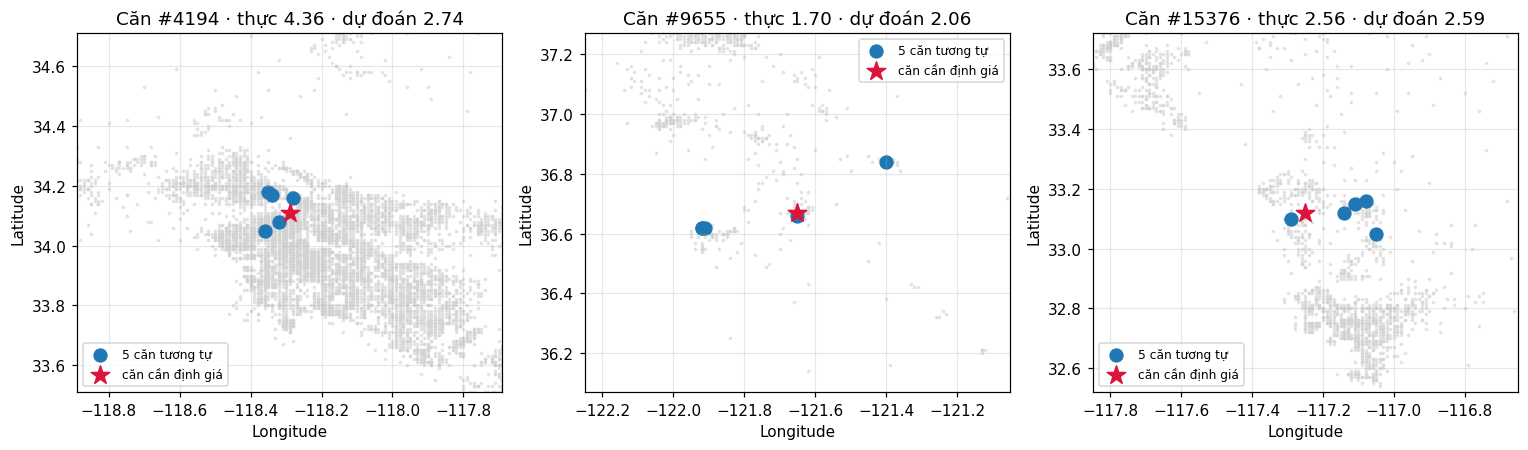

In [10]:
mau = X_test.sample(3, random_state=RANDOM_STATE).index

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, i in zip(axes, mau):
    x_q = X_test.loc[[i]]
    bang_tt, du_doan = cac_can_tuong_tu(knn, X_train, y_train, x_q, k=5)
    thuc = y_test.loc[i]
    print(f"\n{'='*100}\nCăn #{i} — giá thực {thuc:.2f} · KNN ước tính {du_doan:.2f} (100.000 USD)")
    display(pd.concat([x_q.assign(Gia_thuc=thuc, Khoang_cach=0.0).rename(index={i: "CẦN ĐỊNH GIÁ"}),
                       bang_tt]).round(3))

    ax.scatter(X_train.Longitude, X_train.Latitude, s=2, c="lightgray", alpha=.5)
    ax.scatter(bang_tt.Longitude, bang_tt.Latitude, s=70, c="tab:blue", label="5 căn tương tự")
    ax.scatter(x_q.Longitude, x_q.Latitude, s=160, marker="*", c="crimson", label="căn cần định giá")
    r = .6
    ax.set(xlim=(x_q.Longitude.iloc[0]-r, x_q.Longitude.iloc[0]+r),
           ylim=(x_q.Latitude.iloc[0]-r, x_q.Latitude.iloc[0]+r),
           xlabel="Longitude", ylabel="Latitude",
           title=f"Căn #{i} · thực {thuc:.2f} · dự đoán {du_doan:.2f}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(BC / "can_tuong_tu_vi_du.png"); plt.show()

> **Kiểm tra bằng mắt:** các căn tương tự có thật sự nằm gần nhau trên bản đồ, có mức thu nhập
> (`MedInc`) và số phòng xấp xỉ nhau không? Nếu có — mô hình đang so sánh đúng thứ mà một thẩm
> định viên sẽ so sánh. Câu giải thích cho khách hàng: *"Căn này ước tính X tỷ, dựa trên 5 căn
> tương tự đã bán gần đây: ..."*

## 10. Bảng so sánh cuối: Linear (TT-11) vs KNN (TT-21) vs Random Forest

In [11]:
bang_cuoi = pd.DataFrame([
    danh_gia(Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())]), "Linear Regression (TT-11)"),
    danh_gia(knn, "KNN Regressor (TT-21)"),
    danh_gia(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), "Random Forest"),
])
bang_cuoi["Giải thích được?"] = ["Có — hệ số từng đặc trưng",
                                 "Có — chỉ ra ĐÚNG các căn tương tự",
                                 "Khó — 200 cây, chỉ có feature importance"]
bang_cuoi

,Mô hình,RMSE_train,RMSE_test,R2_test,Train (s),Dự đoán 1 căn (ms),Giải thích được?
0,Linear Regression (TT-11),0.6712,0.6789,0.6515,0.0159,1.3813,Có — hệ số từng đặc trưng
1,KNN Regressor (TT-21),0.0000,0.4785,0.8269,0.0253,91.7080,Có — chỉ ra ĐÚNG các căn tương tự
2,Random Forest,0.1844,0.4957,0.8142,5.3257,67.3961,"Khó — 200 cây, chỉ có feature importance"


> **Đọc bảng theo 3 trục, không chỉ RMSE:**
> - **Độ chính xác:** Random Forest thường tốt nhất, KNN thắng Linear Regression rõ rệt.
> - **Thời gian:** Linear/RF train xong là dự đoán tức thì; KNN train ~0 giây (chỉ lưu dữ liệu)
>   nhưng **trả nợ ở lúc dự đoán** — mỗi lần phải quét toàn bộ tập train.
> - **Giải thích:** chỉ KNN đưa ra được *bằng chứng cụ thể* — đúng thứ sàn BĐS cần hiển thị cho khách.

## 11. ⚠️ KNN chậm dần khi dữ liệu lớn

Nhân bản tập train 1× / 5× / 10× (kèm nhiễu nhỏ để không trùng khít) rồi đo lại thời gian dự đoán.

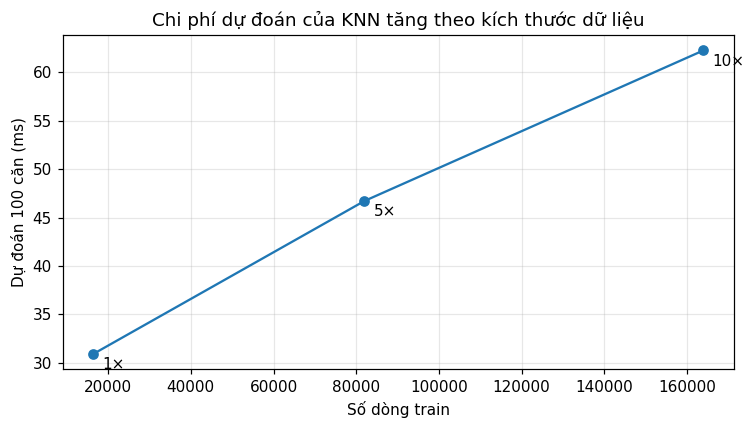

,Bội số,Số dòng train,Dự đoán 1 căn (ms),Dự đoán 100 căn (ms)
0,1×,16396,31.8397,30.9222
1,5×,81980,31.2034,46.7132
2,10×,163960,31.7091,62.2491


In [12]:
rng = np.random.default_rng(RANDOM_STATE)
lo_100 = X_test.iloc[:100]
dong = []
for h in (1, 5, 10):
    Xb = pd.concat([X_train] + [X_train * (1 + rng.normal(0, .01, X_train.shape)) for _ in range(h-1)],
                   ignore_index=True)
    yb = pd.concat([y_train] * h, ignore_index=True)
    pipe = tao_pipeline(k=K_TOT, weights=WEIGHTS_TOT, metric=METRIC_TOT, w_vi_tri=W_TOT).fit(Xb, yb)
    pipe.predict(lo_100.iloc[[0]])
    t0 = time.perf_counter()
    for _ in range(20): pipe.predict(lo_100.iloc[[0]])
    t1 = (time.perf_counter() - t0) / 20 * 1000
    t0 = time.perf_counter(); pipe.predict(lo_100); t100 = (time.perf_counter() - t0) * 1000
    dong.append({"Bội số": f"{h}×", "Số dòng train": len(Xb),
                 "Dự đoán 1 căn (ms)": t1, "Dự đoán 100 căn (ms)": t100})
bang_tg = pd.DataFrame(dong)

plt.figure(figsize=(7, 4))
plt.plot(bang_tg["Số dòng train"], bang_tg["Dự đoán 100 căn (ms)"], "o-")
for _, r in bang_tg.iterrows():
    plt.annotate(r["Bội số"], (r["Số dòng train"], r["Dự đoán 100 căn (ms)"]),
                 textcoords="offset points", xytext=(6, -10))
plt.xlabel("Số dòng train"); plt.ylabel("Dự đoán 100 căn (ms)")
plt.title("Chi phí dự đoán của KNN tăng theo kích thước dữ liệu")
plt.tight_layout(); plt.savefig(BC / "thoi_gian_predict.png"); plt.show()
bang_tg

In [13]:
(GOC / "models").mkdir(exist_ok=True)
joblib.dump(knn, GOC / "models" / "knn_pipeline.joblib")
print("Đã lưu models/knn_pipeline.joblib")

Đã lưu models/knn_pipeline.joblib


## 12. Kết luận & hạn chế

**Kết quả chính**
1. **Chuẩn hoá là bắt buộc** — thiếu nó, `Population` áp đảo và KNN thua cả Linear Regression.
2. **KNN thắng Linear Regression** trên bộ này, đúng như kỳ vọng lý thuyết: quan hệ vị trí → giá
   là phi tuyến và cục bộ, đúng "sở trường" của mô hình phi tham số.
3. **Trọng số vị trí** giúp giảm RMSE thêm — bằng chứng định lượng cho câu "location, location, location".
4. **KNN giải thích được** bằng chính các căn nhà cụ thể — ưu thế mà RF/XGBoost không có.

**Hạn chế của KNN**
- **Chậm khi dự đoán**: chi phí tăng tuyến tính theo kích thước tập train (bước 11).
- **Không ngoại suy**: dự đoán luôn nằm trong khoảng giá của tập train → căn đắt hơn mọi căn đã
  thấy sẽ bị *kẹp trần* (ở bộ này còn cộng thêm việc nhãn đã bị chặn tại 5.0).
- **Phải lưu toàn bộ dữ liệu** khi triển khai — không có "công thức" gọn như Linear Regression.
- **Nhạy với đặc trưng nhiễu**: mọi đặc trưng vô dụng đều làm méo khoảng cách.

**Hướng mở rộng**
1. `algorithm='kd_tree'` / `BallTree` để tăng tốc tìm hàng xóm.
2. `RadiusNeighborsRegressor` — lấy mọi căn trong bán kính X km thay vì K căn cố định (sát thực tế thẩm định hơn).
3. Dùng KNN sinh đặc trưng *"giá trung bình 10 căn lân cận"* rồi đưa vào XGBoost — kết hợp
   trực giác địa lý của KNN với sức mạnh của boosting.